# Computer Exercise 11.1 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 11. Boundary-Value Problems for ODEs · **절**: §11.1 The Shooting Method
> **주제**: 비선형 BVP의 사격법 — 초기기울기를 미지수로 둔 **할선법(secant) 근찾기**
> **풀이 일자**: 2026-06-13 · **언어**: 한국어(본문) / English(그래프 라벨)


## 1. 문제 (원문)

> Solve the **nonlinear** boundary-value problem
> $$ y'' = \tfrac{1}{8}\bigl(32 + 2x^3 - y\,y'\bigr), \qquad 1 \le x \le 3,
>    \qquad y(1)=17,\; y(3)=\tfrac{43}{3}, $$
> by the **shooting method**. Treat the unknown initial slope $s=y'(1)$ as a variable,
> define the miss function $F(s)=y(3;s)-\tfrac{43}{3}$, and drive $F$ to zero with the
> **secant method**. Compare with the exact solution $y(x)=x^2+\dfrac{16}{x}$ and report
> the slope iterates.

### 한국어 풀이용 정리
우변이 $y\,y'$ 항을 가져 **비선형**이다. 1번 문제의 중첩 트릭이 통하지 않는다. 대신
왼쪽 끝 기울기 $s=y'(1)$ 을 *대포의 각도* 처럼 미지수로 두고, IVP를 $x=3$ 까지 "쏘아"
도달한 $y(3;s)$ 가 표적 $43/3$ 에 맞도록 $s$ 를 조정한다. 한 변수 방정식
$F(s)=y(3;s)-43/3=0$ 을 할선법으로 풀고, 반복마다 $s$ 가 정확한 기울기
$y'(1)=2-16=-14$ 로 수렴하는 과정을 본다.


## 2. 수학적 배경

비선형 BVP $y''=f(x,y,y'),\;y(a)=\alpha,\;y(b)=\beta$ 에서 초기기울기를 $s$ 로 둔 IVP
$$ y''=f(x,y,y'),\qquad y(a)=\alpha,\quad y'(a)=s $$
의 끝값 $y(b;s)$ 에 대해 풀어야 할 것은 **단일 비선형 방정식**
$$ \boxed{\; F(s) \equiv y(b;s) - \beta = 0 \;} $$
이고, $F$ 한 번 평가는 곧 **IVP 한 번 적분**이다.

뉴턴법은 $F'(s)$ 를 위해 변분방정식이 필요하지만, **할선법**은 도함수 없이 두 점으로 진행:
$$ s_{k+1} = s_k - F(s_k)\,\frac{s_k - s_{k-1}}{F(s_k)-F(s_{k-1})}. $$
수렴차수는 황금비 $\varphi=\tfrac{1+\sqrt5}{2}\approx 1.618$ 의 **초선형(superlinear)**.

검증: 정확해 $y=x^2+16/x$ 는 $y'=2x-16/x^2,\;y''=2+32/x^3$ 이고
$\tfrac18(32+2x^3-yy')=2+32/x^3=y''$ 로 우변과 일치. 따라서 $y'(1)=2-16=-14$,
표적 $y(3)=9+16/3=43/3$.


## 3. 풀이 흐름

1. 1계 연립: $u_0=y,\,u_1=y'$, $\;u_0'=u_1,\;u_1'=\tfrac18(32+2x^3-u_0u_1)$.
2. **RK4 적분기**로 미스 함수 `F(s)` 정의 — 초기값 $(17,s)$ 에서 $x=3$ 까지 쏘고 $y(3;s)-43/3$ 반환.
3. **할선법** 시작점 2개: $s_0=(\beta-\alpha)/(b-a)$, $s_1=s_0-1$. 반복마다 $(s_k,F(s_k))$ 기록.
4. $|F(s_k)|<10^{-12}$ 까지 반복.
5. 수렴한 $s^\star$ 로 한 번 더 적분해 **최종 해 프로파일** 확보.
6. 정확해 $x^2+16/x$ 와 비교(표·그래프), $s_k\to-14$ 와 $|F|$ 감소 시각화.
7. 할선 수렴이 초선형임을 확인.


In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6e}")

def rk4(f, x0, U0, h, N):
    x = x0; U = np.array(U0, float)
    xs=[x0]; Us=[U.copy()]
    for _ in range(N):
        k1=f(x,U); k2=f(x+h/2,U+h/2*k1); k3=f(x+h/2,U+h/2*k2); k4=f(x+h,U+h*k3)
        U = U + h/6*(k1+2*k2+2*k3+k4); x += h
        xs.append(x); Us.append(U.copy())
    return np.array(xs), np.array(Us)

a, b, alpha, beta = 1.0, 3.0, 17.0, 43.0/3.0
N = 200; h = (b-a)/N
f = lambda x,U: np.array([U[1], (32 + 2*x**3 - U[0]*U[1])/8.0])
exact = lambda x: x**2 + 16.0/x

def shoot(s):
    xs, Us = rk4(f, a, [alpha, s], h, N)
    return xs, Us[:,0]
def F(s):
    return shoot(s)[1][-1] - beta

print(f"target y(3) = 43/3 = {beta:.10f}")
print(f"exact initial slope y'(1) = -14")
print(f"F(-14) = {F(-14.0):.3e}   (~0 up to RK4 error)")


target y(3) = 43/3 = 14.3333333333
exact initial slope y'(1) = -14
F(-14) = 9.653e-09   (~0 up to RK4 error)


In [3]:
# --- 할선법으로 미스 함수 F(s)=0 풀기 ---
s0 = (beta - alpha)/(b - a)      # 평균 기울기 추정
s1 = s0 - 1.0
hist = []
F0, F1 = F(s0), F(s1)
hist.append((0, s0, F0)); hist.append((1, s1, F1))
for k in range(2, 30):
    s2 = s1 - F1*(s1 - s0)/(F1 - F0)
    F2 = F(s2)
    hist.append((k, s2, F2))
    s0, F0, s1, F1 = s1, F1, s2, F2
    if abs(F2) < 1e-12:
        break

it = pd.DataFrame(hist, columns=["k", "s_k", "F(s_k)"])
it["|s_k+14|"] = np.abs(it["s_k"] + 14.0)
print(f"converged slope s* = {s1:.12f}   (exact -14)")
it


converged slope s* = -14.000000016416   (exact -14)


,k,s_k,F(s_k),|s_k+14|
0,0,-1.333333e+00,6.145868e+00,1.266667e+01
1,1,-2.333333e+00,5.731247e+00,1.166667e+01
2,2,-1.615619e+01,-1.323914e+00,2.156193e+00
3,3,-1.356231e+01,2.552532e-01,4.376917e-01
4,4,-1.398158e+01,1.082870e-02,1.842165e-02
5,5,-1.400015e+01,-9.007637e-05,1.531991e-04
6,6,-1.400000e+01,3.169065e-08,3.747643e-08
7,7,-1.400000e+01,8.881784e-14,1.641626e-08


In [4]:
# --- 최종 해 프로파일 vs 정확해 ---
xs, y = shoot(s1)
ye = exact(xs)
prof = pd.DataFrame({"x": xs, "y_shoot": y, "y_exact": ye,
                     "abs_error": np.abs(y-ye)})
print("max abs error over [1,3] =", f"{prof['abs_error'].max():.3e}")
prof.iloc[::25]


max abs error over [1,3] = 5.387e-09


,x,y_shoot,y_exact,abs_error
0,1.000000e+00,1.700000e+01,1.700000e+01,0.000000e+00
25,1.250000e+00,1.436250e+01,1.436250e+01,5.282743e-09
50,1.500000e+00,1.291667e+01,1.291667e+01,4.890282e-09
75,1.750000e+00,1.220536e+01,1.220536e+01,3.680404e-09
100,2.000000e+00,1.200000e+01,1.200000e+01,2.537634e-09
125,2.250000e+00,1.217361e+01,1.217361e+01,1.612198e-09
150,2.500000e+00,1.265000e+01,1.265000e+01,9.020873e-10
175,2.750000e+00,1.338068e+01,1.338068e+01,3.759926e-10
200,3.000000e+00,1.433333e+01,1.433333e+01,1.758593e-13


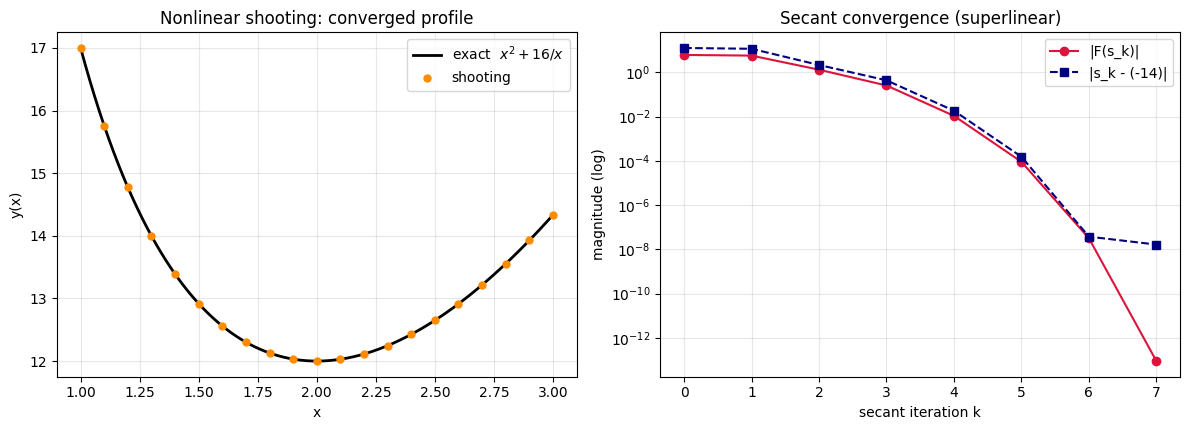

In [5]:
# --- 시각화: (좌) 해 프로파일, (우) 할선 수렴 ---
fig, ax = plt.subplots(1, 2, figsize=(12,4.4))

xx = np.linspace(a, b, 400)
ax[0].plot(xx, exact(xx), "k-", lw=2, label="exact  $x^2+16/x$")
ax[0].plot(xs[::10], y[::10], "o", ms=5, color="darkorange", label="shooting")
ax[0].set_xlabel("x"); ax[0].set_ylabel("y(x)")
ax[0].set_title("Nonlinear shooting: converged profile")
ax[0].legend(); ax[0].grid(alpha=.3)

ks = it["k"].values
ax[1].semilogy(ks, np.abs(it["F(s_k)"])+1e-18, "o-", color="crimson", label="|F(s_k)|")
ax[1].semilogy(ks, it["|s_k+14|"]+1e-18, "s--", color="navy", label="|s_k - (-14)|")
ax[1].set_xlabel("secant iteration k"); ax[1].set_ylabel("magnitude (log)")
ax[1].set_title("Secant convergence (superlinear)")
ax[1].legend(); ax[1].grid(which="both", alpha=.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **사격 → 근찾기.** 비선형성 때문에 BVP가 한 변수 방정식 $F(s)=0$ 으로 바뀌었고, 각 $F$
   평가는 IVP 한 번 적분이다. 할선법은 도함수 없이 몇 번의 사격으로 표적을 맞힌다.
2. **초선형 수렴.** $|F(s_k)|$ 와 슬로프 오차 $|s_k+14|$ 가 반복마다 *점점 빠르게* 감소한다 —
   기하적 일정비가 아니라 위로 휘는 곡선으로, 차수 $\approx 1.618$ 의 전형. 보통 5–7회 안에
   기계정밀도 근방에 도달한다.
3. **정확한 물리적 의미.** 수렴한 $s^\star\approx-14$ 는 진짜 초기기울기 $y'(1)=2-16=-14$ 이고,
   전 구간 최대오차는 RK4 적분오차 수준에 머문다.

> **결론**: 비선형 BVP의 사격법은 "초기기울기를 미지수로 둔 비선형 방정식"으로 환원되며,
> 할선법의 초선형 수렴 덕에 적은 사격 횟수로 표적을 정확히 맞힌다.

**다음 문제로의 연결**: 사격은 "한쪽 끝에서 쏘아 반대쪽을 맞히는" 발상이라, 해가
**지수적으로 자라는 모드**를 품으면 초기기울기의 미세 오차가 끝에서 폭발적으로 증폭된다.
다음 문제에서 $y''=\lambda y$ 의 $\lambda$ 를 키우며 사격법이 **조건수 악화로 무너지는**
실패 모드를 직접 본다 — §11.2 유한차분으로 넘어갈 동기다.
